In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Cargar datos necesarios (escalados para Bayes, crudos para el Árbol)
X_train_scaled = pd.read_csv('../Datos/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../Datos/X_test_scaled.csv')
X_train_raw = pd.read_csv('../Datos/X_train_raw.csv')
X_test_raw = pd.read_csv('../Datos/X_test_raw.csv')

y_train = pd.read_csv('../Datos/y_train.csv').values.ravel()
y_test = pd.read_csv('../Datos/y_test.csv').values.ravel()

especies_nombres = ['H. yagouaroundi', 'L. geoffroyi', 'L. guigna', 'L. pardalis', 'P. onca', 'P. concolor']

# =====================================================================
# NAIVE BAYES (Gaussian Naive Bayes)
# =====================================================================
print("Entrenando Gaussian Naive Bayes...")
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

# =====================================================================
# ÁRBOL DE DECISIÓN (Decision Tree)
# =====================================================================
print("Entrenando Árbol de Decisión...")
# Controlamos la profundidad máxima (max_depth=5) para evitar overfitting inicial
# Usamos 'entropy' como criterio de división (Ganancia de Información de Shannon)
tree = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
tree.fit(X_train_raw, y_train)
y_pred_tree = tree.predict(X_test_raw)

# =====================================================================
# EVALUACIÓN COMPARATIVA
# =====================================================================
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_tree = accuracy_score(y_test, y_pred_tree)

print("\n" + "="*40)
print(f"Accuracy Global - Naive Bayes: {acc_nb:.4f}")
print(f"Accuracy Global - Árbol de Decisión: {acc_tree:.4f}")
print("="*40)


Entrenando Gaussian Naive Bayes...
Entrenando Árbol de Decisión...

Accuracy Global - Naive Bayes: 0.5787
Accuracy Global - Árbol de Decisión: 0.7670


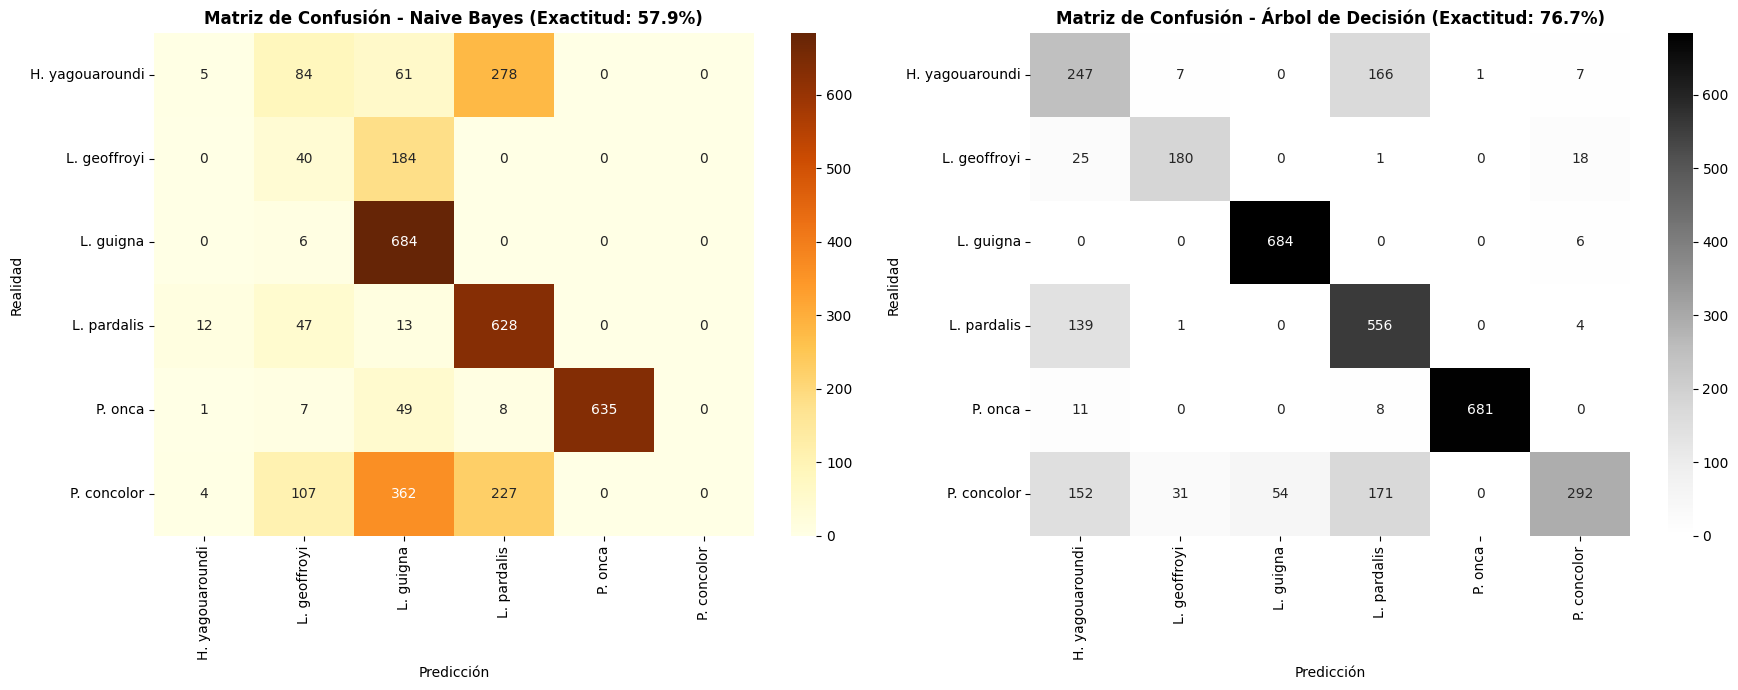

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt="d", cmap="YlOrBr", xticklabels=especies_nombres, yticklabels=especies_nombres, ax=axes[0])
axes[0].set_title(f'Matriz de Confusión - Naive Bayes (Exactitud: {acc_nb*100:.1f}%)', fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Realidad')

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", cmap="Greys", xticklabels=especies_nombres, yticklabels=especies_nombres, ax=axes[1])
axes[1].set_title(f'Matriz de Confusión - Árbol de Decisión (Exactitud: {acc_tree*100:.1f}%)', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()


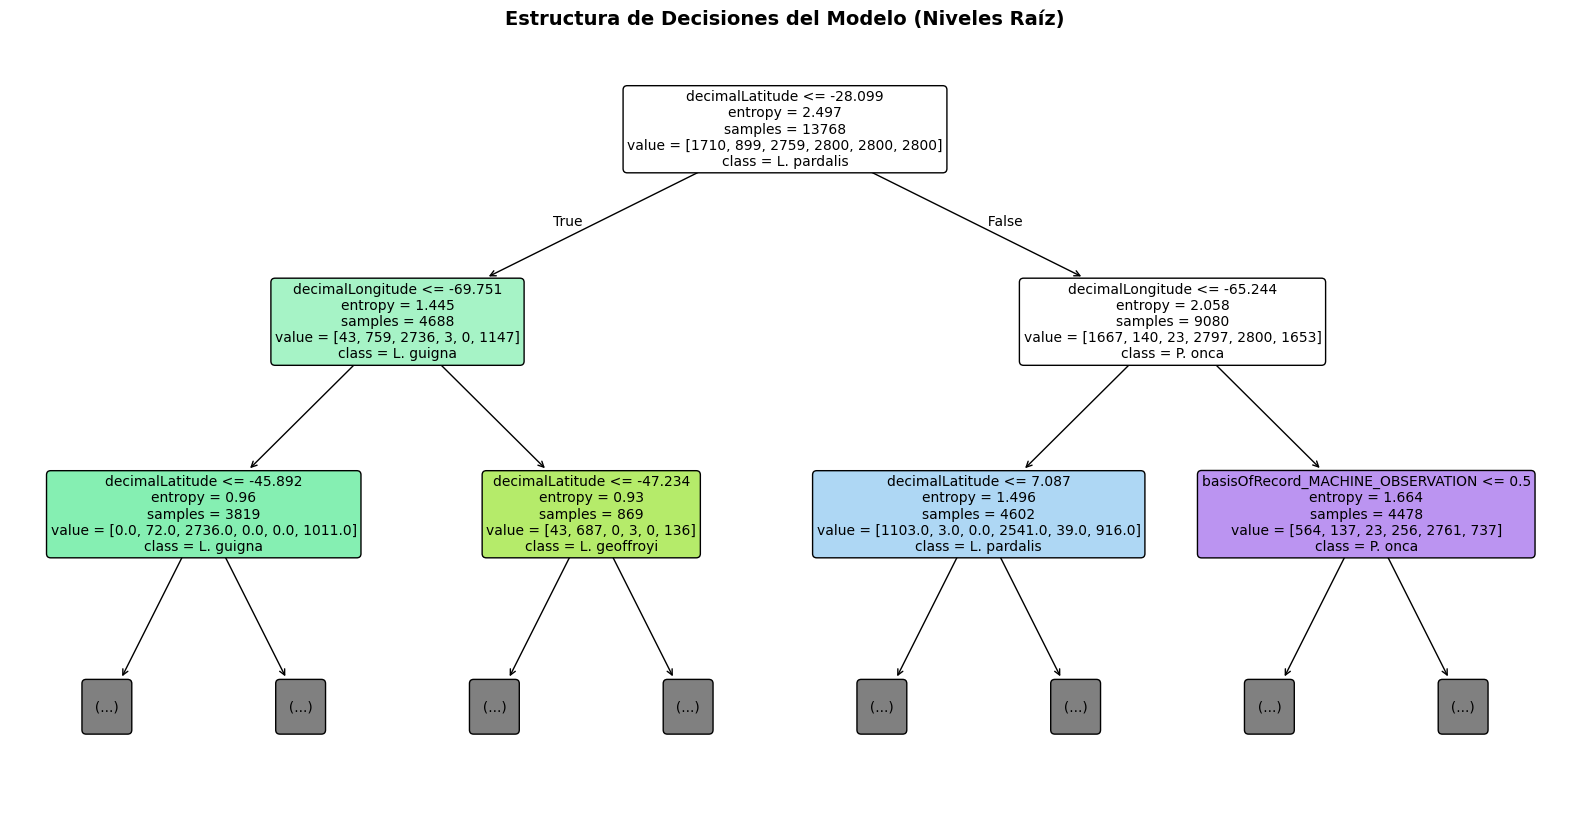

In [3]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree, 
    feature_names=X_train_raw.columns, 
    class_names=especies_nombres, 
    filled=True, 
    rounded=True, 
    max_depth=2, 
    fontsize=10
)
plt.title("Estructura de Decisiones del Modelo (Niveles Raíz)", fontsize=14, fontweight='bold')
plt.show()


### Teorema de Bayes vs. Entropía de Shannon en Espacios Geográficos

El contraste en el desempeño de ambos modelos ofrece una lección teórica fundamental sobre los supuestos de los algoritmos:

1.  **La Variable Raíz y la Ganancia de Información:**
    El Árbol de Decisión seleccionó `decimalLatitude` como su nodo raíz. Basado en la Entropía de Shannon, este corte ortogonal es el que genera la mayor pureza de clases instantánea. Esto tiene un sentido biológico estricto: la latitud dicta las zonas climáticas de Sudamérica, separando de inmediato los hábitats templados fríos de la Patagonia (Güiña y Gato Montés) de las zonas tropicales del norte (Yaguareté y Ocelote). El modelo logra una exactitud sólida del **76.7%** con una profundidad de solo 5 niveles.
2.  **El Fracaso del Supuesto Inocente (Naive Bayes - 57.9%):**
    Gaussian Naive Bayes asume de forma estricta que todas las variables son independientes entre sí. En nuestro dataset, la Latitud, Longitud y los Países (*One-Hot Encoded*) están intrínsecamente entrelazados por la geografía. Al violarse este supuesto, el modelo sufre de un sesgo probabilístico severo, tendiendo a amontonar las predicciones hacia el Ocelote (*L. pardalis*) y la Güiña (*L. guigna*) como se observa en su matriz de confusión.
